In [17]:
import pandas as pd

target_groups = ['m3049','mover50', 'fover50', 'm1229', 'f3049', 'f1229']
channel_list = [0,3501,3403,3404,3303,3302,3401,3402,3306,3301,3400,3305,3304,3300,3103,3101,3100,3102]

df = pd.read_csv("concurrent_weighted_viewers.csv")
df["ts"] = pd.to_datetime(df["ts"])

In [5]:
df.dtypes

tv_date                    str
channel_id               int64
target_group               str
ts              datetime64[us]
num_sessions             int64
weighted_sum           float64
dtype: object

In [28]:
df = df[df["tv_date"] == "2025-09-07"]
group = "m1229"

group_data = df[df['target_group'] == group]
print(group_data.shape)
group_data.head()

(14595, 6)


,tv_date,channel_id,target_group,ts,num_sessions,weighted_sum
55631,2025-09-07,0,m1229,2025-09-07 01:00:00,6,68.736364
55632,2025-09-07,0,m1229,2025-09-07 01:01:54,1,33.137522
55633,2025-09-07,0,m1229,2025-09-07 01:01:57,1,28.403590
55634,2025-09-07,0,m1229,2025-09-07 01:02:00,1,33.137522
55635,2025-09-07,0,m1229,2025-09-07 01:02:01,1,28.403590


In [33]:
import matplotlib.pyplot as plt

def plot_target_group(df, tv_date, group, ymax):
    # Filter and sort once
    filtered_df = df[(df["tv_date"] == tv_date) & (df["target_group"]==group)].sort_values('ts')

    # Create line plot with ts as x-axis
    plt.figure(figsize=(14, 7))

    for channel_id, data in filtered_df.groupby('channel_id'):
        plt.plot(data['ts'], data['weighted_sum'], label=f'Channel {channel_id}')

    plt.xlabel('Timestamp')
    plt.ylabel('Weighted Sum')
    plt.title('Weighted Viewers by Channel ID Over Time')
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.ylim(0, ymax) if ymax else None
    plt.show()

    print(f"Total records: {len(filtered_df)}, Channels: {filtered_df['channel_id'].nunique()}")

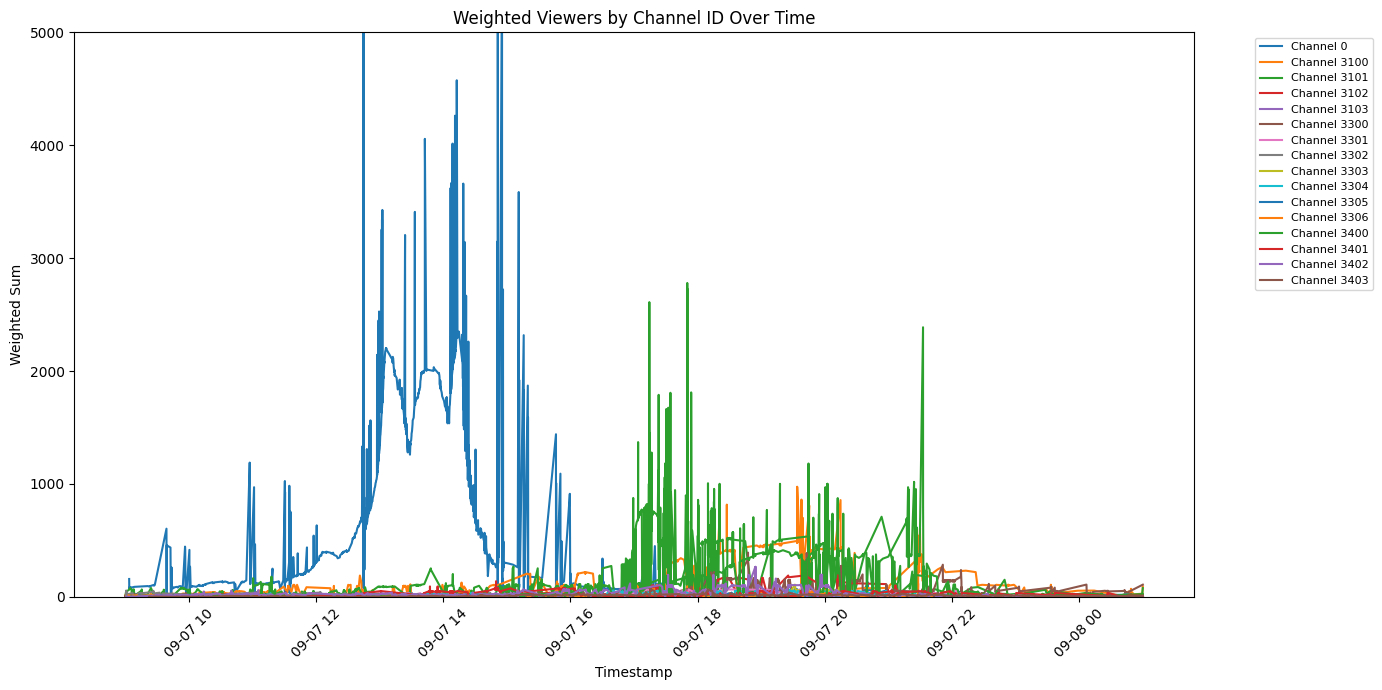

Total records: 11825, Channels: 16


In [38]:
plot_target_group(df[df["ts"] >pd.to_datetime("2025-09-07 09:00") ], tv_date="2025-09-07",group="m1229", ymax=5000)

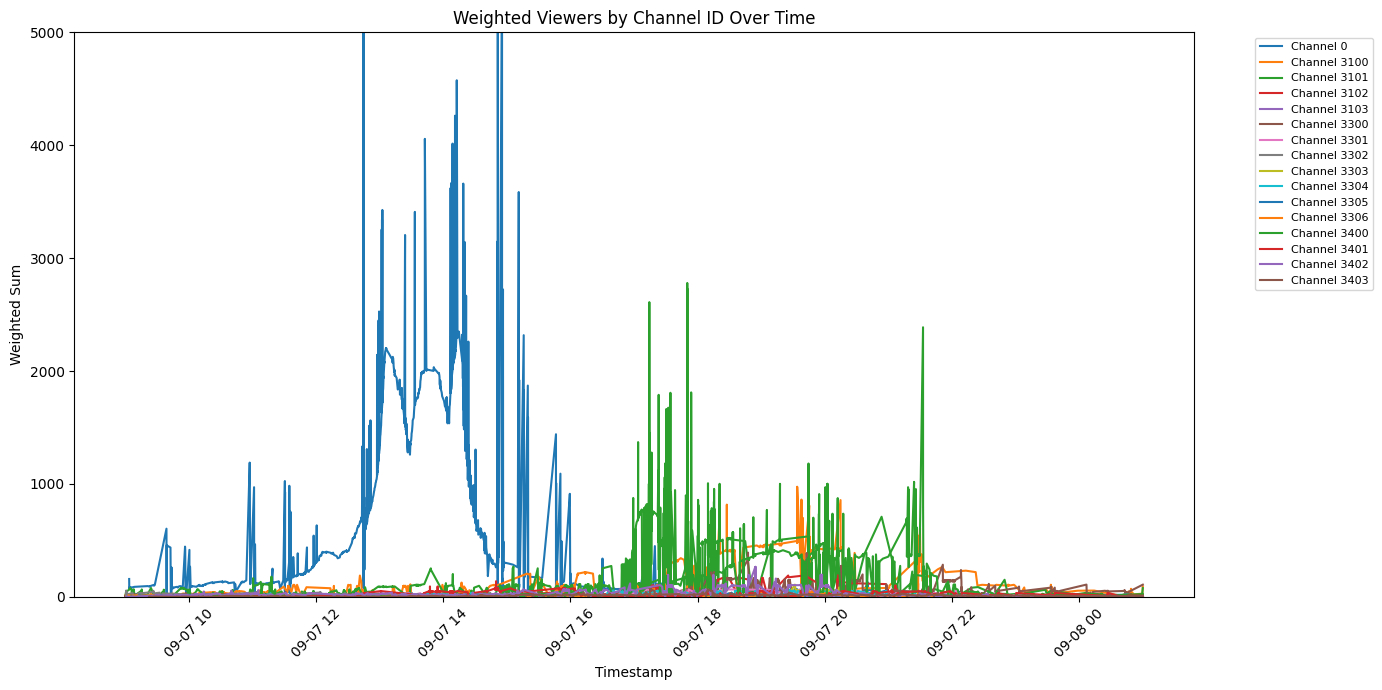

Total records: 11825, Channels: 16


In [35]:
plot_target_group(df[df["ts"] >pd.to_datetime("2025-09-07 09:00") ], tv_date="2025-09-07",group="m1229", ymax=5000)

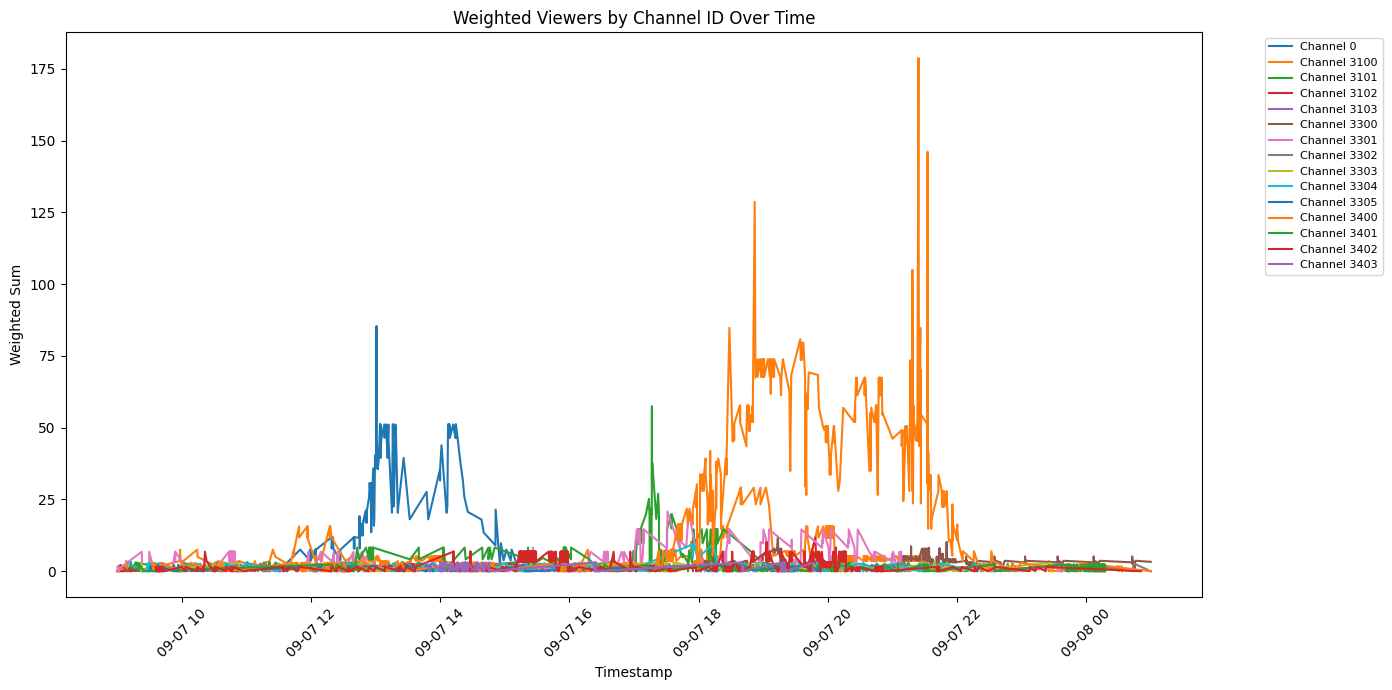

Total records: 4496, Channels: 15


In [16]:
plot_target_group(df[df["ts"] >pd.to_datetime("2025-09-07 09:00") ], tv_date="2025-09-07",group="f1229")

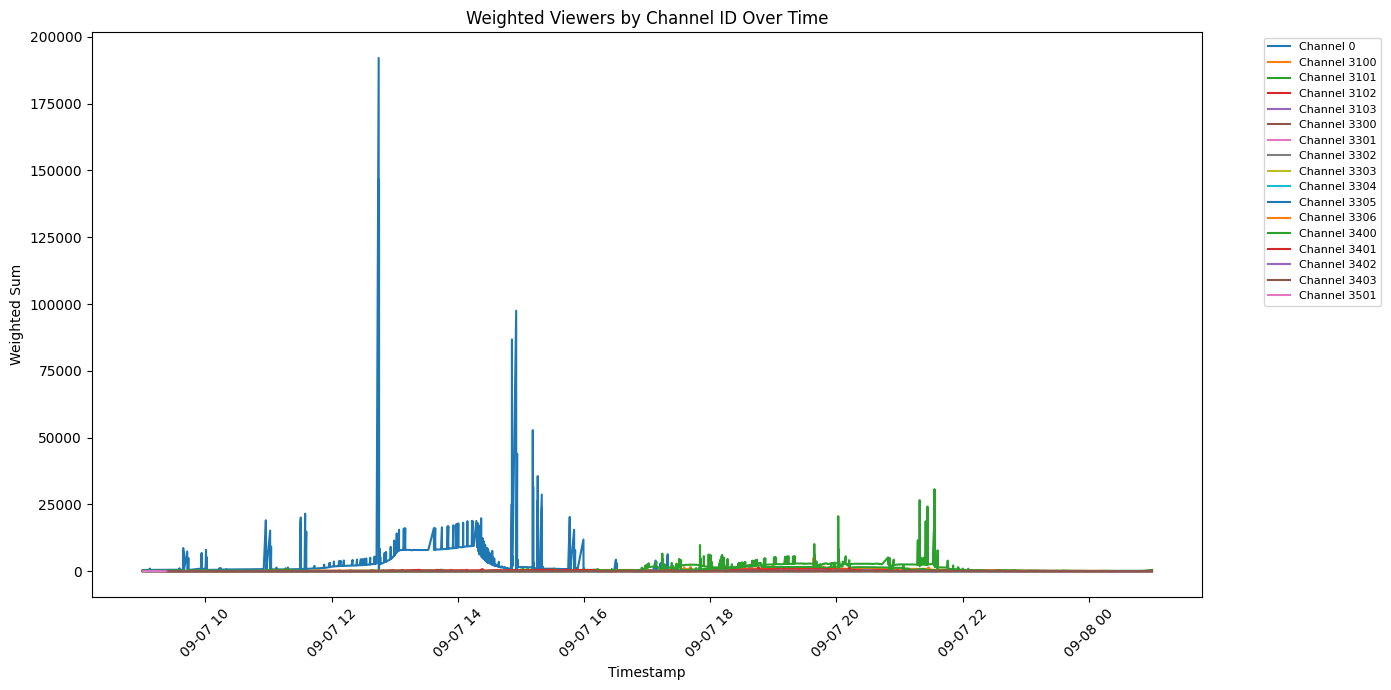

Total records: 12337, Channels: 17


In [29]:
plot_target_group(df[df["ts"] >pd.to_datetime("2025-09-07 09:00") ], tv_date="2025-09-07",group="m3049")

In [28]:
df[df["target_group"]=="m3049"].sort_values("weighted_sum", ascending=False).head()

,tv_date,channel_id,target_group,ts,num_sessions,weighted_sum
57866,2025-09-07,0,m3049,2025-09-07 12:44:43,157,192089.208441
57874,2025-09-07,0,m3049,2025-09-07 12:45:01,137,146706.733725
58585,2025-09-07,0,m3049,2025-09-07 14:55:28,97,97487.714552
58577,2025-09-07,0,m3049,2025-09-07 14:51:26,100,86750.993458
58625,2025-09-07,0,m3049,2025-09-07 15:11:14,75,52795.358138


In [32]:
df[(df["target_group"]=="m3049") & (df["ts"] >= pd.to_datetime("2025-09-07 12:42:00")) & (df["ts"] <= pd.to_datetime("2025-09-07 12:45:00"))]

,tv_date,channel_id,target_group,ts,num_sessions,weighted_sum
57862,2025-09-07,0,m3049,2025-09-07 12:42:23,1,2851.254170
57863,2025-09-07,0,m3049,2025-09-07 12:42:37,1,2869.817954
57864,2025-09-07,0,m3049,2025-09-07 12:42:38,1,2852.529894
57865,2025-09-07,0,m3049,2025-09-07 12:42:39,1,2869.817954
57866,2025-09-07,0,m3049,2025-09-07 12:44:43,157,192089.208441
57867,2025-09-07,0,m3049,2025-09-07 12:44:44,1,104.135906
57868,2025-09-07,0,m3049,2025-09-07 12:44:45,1,97.295756
57869,2025-09-07,0,m3049,2025-09-07 12:44:47,1,95.313437
57870,2025-09-07,0,m3049,2025-09-07 12:44:51,1,31.387187
57871,2025-09-07,0,m3049,2025-09-07 12:44:52,1,26.903303


# Compare to Synthetic Viewer Sessions

In [3]:
import pandas as pd
import duckdb

db_path = r"C:\Users\kialb\GitHub\Red Bull Case Study\DuckDB\sessions.duckdb"

conn = duckdb.connect(database=db_path, read_only=True)


viewer_sessions_df = pd.read_sql(f"""
SELECT 
sesh.channel_id,
sesh.viewer_id,
sesh.session_start,
sesh.session_finish,
sesh.session_duration,
vw.viewer_weight,
dtg.id AS target_group
FROM viewer_sessions sesh
LEFT JOIN viewer_weights vw
ON sesh.viewer_id = vw.viewer
LEFT JOIN digital_target_group_mappings dtg
ON dtg.target_group = vw.target_group
WHERE sesh.tv_day = '2025-09-07'
""", conn)

C:\Users\kialb\AppData\Local\Temp\ipykernel_23328\248434984.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  viewer_sessions_df = pd.read_sql(f"""


In [5]:
viewer_sessions_df.head()

,channel_id,viewer_id,session_start,session_finish,session_duration,viewer_weight,target_group
0,0,29639_25,2025-09-07 16:02:24,2025-09-07 16:03:59,96,92.205623,f3049
1,0,30060_23,2025-09-07 16:53:33,2025-09-07 16:55:17,105,53.936444,fover50
2,0,28906_22,2025-09-07 20:31:56,2025-09-07 20:33:57,122,56.280497,mover50
3,0,23605_17,2025-09-07 13:25:14,2025-09-07 13:27:15,122,115.427426,fover50
4,0,4017_28,2025-09-07 19:37:09,2025-09-07 19:39:11,123,23.024188,fover50


In [9]:
import pandas as pd
import duckdb

db_path = r"C:\Users\kialb\GitHub\Red Bull Case Study\DuckDB\sessions.duckdb"
conn = duckdb.connect(database=db_path, read_only=True)

viewer_sessions_weighted_sum_df = pd.read_sql(f"""
WITH main AS (SELECT 
sesh.channel_id,
sesh.viewer_id,
sesh.session_start,
sesh.session_finish,
sesh.session_duration,
tg.viewer_weight,
tg.id AS target_group
FROM viewer_sessions sesh
JOIN (SELECT DISTINCT viewer, viewer_weight, id from viewer_weights vw
JOIN digital_target_group_mappings dtg
ON dtg.target_group = vw.target_group) tg
ON sesh.viewer_id = tg.viewer
WHERE sesh.tv_day='2025-09-07')


SELECT 
ts, target_group, channel_id, 
SUM(change) OVER (
PARTITION BY channel_id, target_group
ORDER BY ts ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS weighted_sum

FROM
(SELECT 
session_start AS ts, target_group, channel_id, 1 AS change, 'start' AS session_event, viewer_weight, viewer_id
FROM main

UNION ALL 

SELECT
session_finish AS ts, target_group, channel_id, -1 AS change, 'end' AS session_event, viewer_weight, viewer_id
FROM main)

""", conn)
viewer_sessions_weighted_sum_df["ts"] = pd.to_datetime(viewer_sessions_weighted_sum_df["ts"])

C:\Users\kialb\AppData\Local\Temp\ipykernel_23328\1706041540.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  viewer_sessions_weighted_sum_df = pd.read_sql(f"""


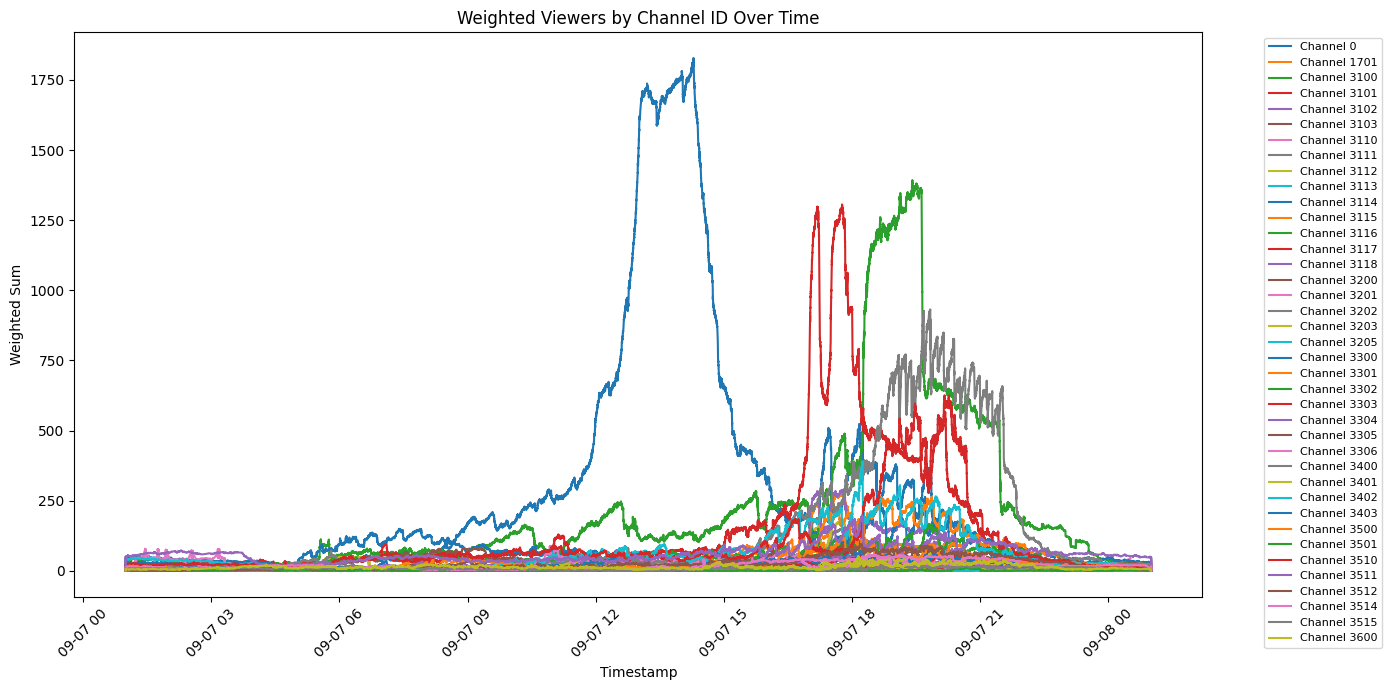

Total records: 417144, Channels: 39


In [15]:
import matplotlib.pyplot as plt

group = "m3049"
# Filter and sort once
filtered_df = viewer_sessions_weighted_sum_df[viewer_sessions_weighted_sum_df["target_group"]==group].sort_values('ts')

# Create line plot with ts as x-axis
plt.figure(figsize=(14, 7))

for channel_id, data in filtered_df.groupby('channel_id'):
    plt.plot(data['ts'], data["weighted_sum"], label=f'Channel {channel_id}')

plt.xlabel('Timestamp')
plt.ylabel('Weighted Sum')
plt.title('Weighted Viewers by Channel ID Over Time')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Total records: {len(filtered_df)}, Channels: {filtered_df['channel_id'].nunique()}")

# Compare to Digital Sessions

In [10]:
import pandas as pd
import duckdb

db_path = r"C:\Users\kialb\GitHub\Red Bull Case Study\DuckDB\sessions.duckdb"
conn = duckdb.connect(database=db_path, read_only=True)

digital_sessions_sum_df = pd.read_sql(f"""
SELECT 
ts, target_group, channel_id, 
SUM(change) OVER (
PARTITION BY channel_id, target_group
ORDER BY ts ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS weighted_sum

FROM
(SELECT 
session_start AS ts, target_group, channel_id, 1 AS change, 'start' AS session_event
FROM digital_20250907_sessions

UNION ALL 

SELECT
session_finish AS ts, target_group, channel_id, -1 AS change, 'end' AS session_event
FROM digital_20250907_sessions)

""", conn)
digital_sessions_sum_df["ts"] = pd.to_datetime(digital_sessions_sum_df["ts"])

C:\Users\kialb\AppData\Local\Temp\ipykernel_23328\2342751776.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  digital_sessions_sum_df = pd.read_sql(f"""


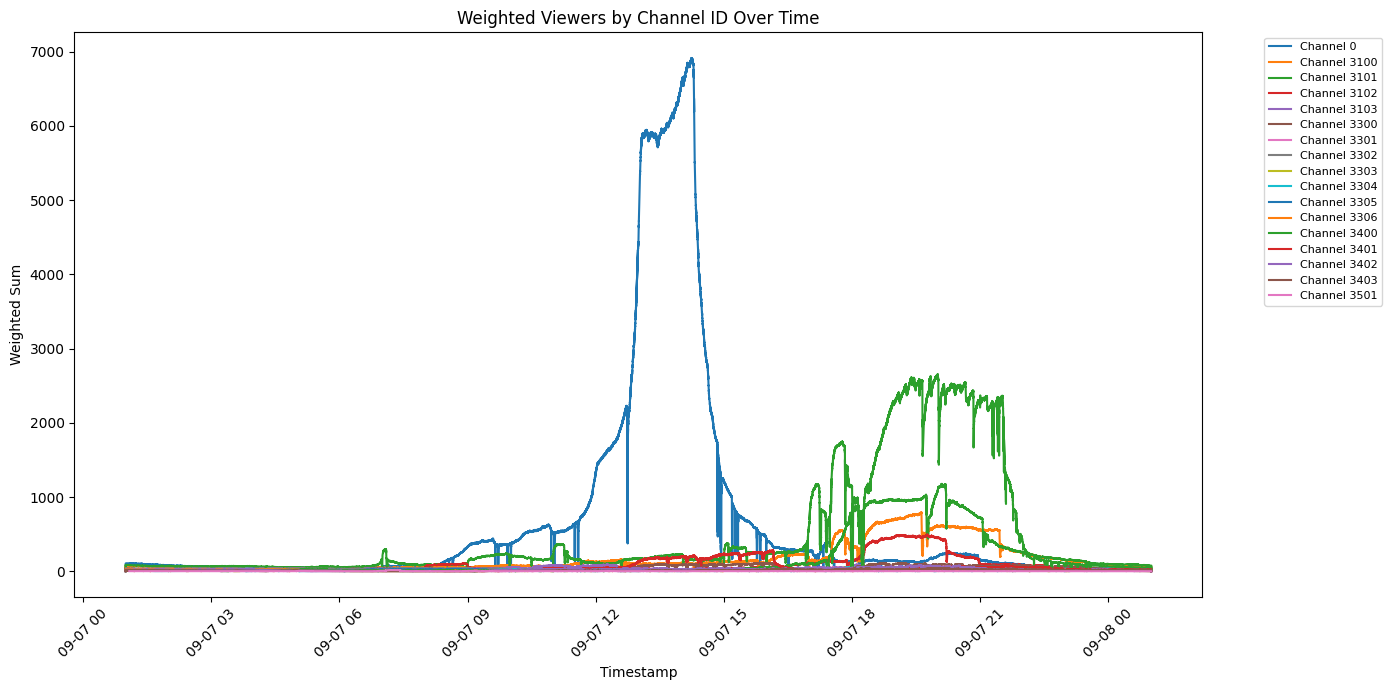

Total records: 1141358, Channels: 17


In [16]:
import matplotlib.pyplot as plt

group = "m3049"
# Filter and sort once
filtered_df = digital_sessions_sum_df[digital_sessions_sum_df["target_group"]==group].sort_values('ts')

# Create line plot with ts as x-axis
plt.figure(figsize=(14, 7))

for channel_id, data in filtered_df.groupby('channel_id'):
    plt.plot(data['ts'], data["weighted_sum"], label=f'Channel {channel_id}')

plt.xlabel('Timestamp')
plt.ylabel('Weighted Sum')
plt.title('Weighted Viewers by Channel ID Over Time')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Total records: {len(filtered_df)}, Channels: {filtered_df['channel_id'].nunique()}")

# Raw Output Data and Trace Individual Active Viewer Session

In [11]:
import pandas as pd
import duckdb

db_path = r"C:\Users\kialb\GitHub\Red Bull Case Study\DuckDB\sessions.duckdb"
conn = duckdb.connect(database=db_path, read_only=True)

active_sessions_df = pd.read_sql(f"""
SELECT * FROM output_active_sessions WHERE tv_date = '2025-09-07'
""", conn)
active_sessions_df["session_start"] = pd.to_datetime(active_sessions_df["session_start"])
active_sessions_df["session_finish"] = pd.to_datetime(active_sessions_df["session_finish"])

C:\Users\kialb\AppData\Local\Temp\ipykernel_23328\2232524753.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  active_sessions_df = pd.read_sql(f"""


In [12]:
import pandas as pd
import duckdb

db_path = r"C:\Users\kialb\GitHub\Red Bull Case Study\DuckDB\sessions.duckdb"
conn = duckdb.connect(database=db_path, read_only=True)

digital_viewers_sum_df = pd.read_sql(f"""
SELECT 
ts, target_group, channel_id, viewer_id, viewer_weight,
SUM(change * viewer_weight) OVER (
PARTITION BY viewer_id
ORDER BY ts ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS weighted_sum

FROM
(SELECT 
session_start AS ts, target_group, channel_id, 1 AS change, 'start' AS session_event, viewer_id, viewer_weight
FROM output_active_sessions WHERE tv_date = '2025-09-07'

UNION ALL 

SELECT
session_finish AS ts, target_group, channel_id, -1 AS change, 'end' AS session_event, viewer_id, viewer_weight
FROM output_active_sessions WHERE tv_date = '2025-09-07')

""", conn)
digital_viewers_sum_df["ts"] = pd.to_datetime(digital_viewers_sum_df["ts"])
digital_viewers_sum_df.head()

C:\Users\kialb\AppData\Local\Temp\ipykernel_23328\155352955.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  digital_viewers_sum_df = pd.read_sql(f"""


,ts,target_group,channel_id,viewer_id,viewer_weight,weighted_sum
0,2025-09-07 12:36:21,fover50,3401,466_30,7.833955,7.833955
1,2025-09-07 12:40:25,fover50,3401,466_30,7.833955,0.000000
2,2025-09-07 12:41:11,fover50,3401,466_30,7.833955,7.833955
3,2025-09-07 14:27:53,fover50,3401,466_30,7.833955,0.000000
4,2025-09-07 14:28:22,fover50,3401,466_30,7.833955,7.833955


In [13]:
digital_viewers_sum_df[digital_viewers_sum_df["weighted_sum"] > 0].groupby("viewer_id").agg("count").sort_values("weighted_sum", ascending=False)

,ts,target_group,channel_id,viewer_weight,weighted_sum
viewer_id,,,,,
23993_30,475,476,476,476,476
29225_23,441,441,441,441,441
27357_26,339,341,341,341,341
27599_28,295,299,299,299,299
9592_27,297,297,297,297,297
...,...,...,...,...,...
27425_25,1,1,1,1,1
11212_29,1,1,1,1,1
10759_30,1,1,1,1,1


In [17]:
active_sessions_df[active_sessions_df["viewer_id"]=="29245_21"]

,tv_date,channel_id,target_group,viewer_id,session_start,session_finish,session_duration,viewer_weight
892,2025-09-07,3300,m3049,29245_21,2025-09-07 05:22:44,2025-09-07 05:26:35,231.0,9.144903
893,2025-09-07,3300,m3049,29245_21,2025-09-07 06:52:45,2025-09-07 06:58:26,341.0,9.144903
894,2025-09-07,3300,m3049,29245_21,2025-09-07 11:04:03,2025-09-07 11:04:09,6.0,9.144903
895,2025-09-07,3300,m3049,29245_21,2025-09-07 14:45:35,2025-09-07 14:48:19,164.0,9.144903
896,2025-09-07,3300,m3049,29245_21,2025-09-07 17:02:56,2025-09-07 17:09:59,423.0,9.144903
...,...,...,...,...,...,...,...,...
38985,2025-09-07,3300,m3049,29245_21,2025-09-07 07:37:44,2025-09-07 07:55:13,1049.0,9.144903
38986,2025-09-07,3300,m3049,29245_21,2025-09-07 11:41:14,2025-09-07 11:46:54,340.0,9.144903
38987,2025-09-07,3300,m3049,29245_21,2025-09-07 16:47:48,2025-09-07 16:47:57,9.0,9.144903
38988,2025-09-07,3300,m3049,29245_21,2025-09-07 18:16:46,2025-09-07 18:48:02,1876.0,9.144903


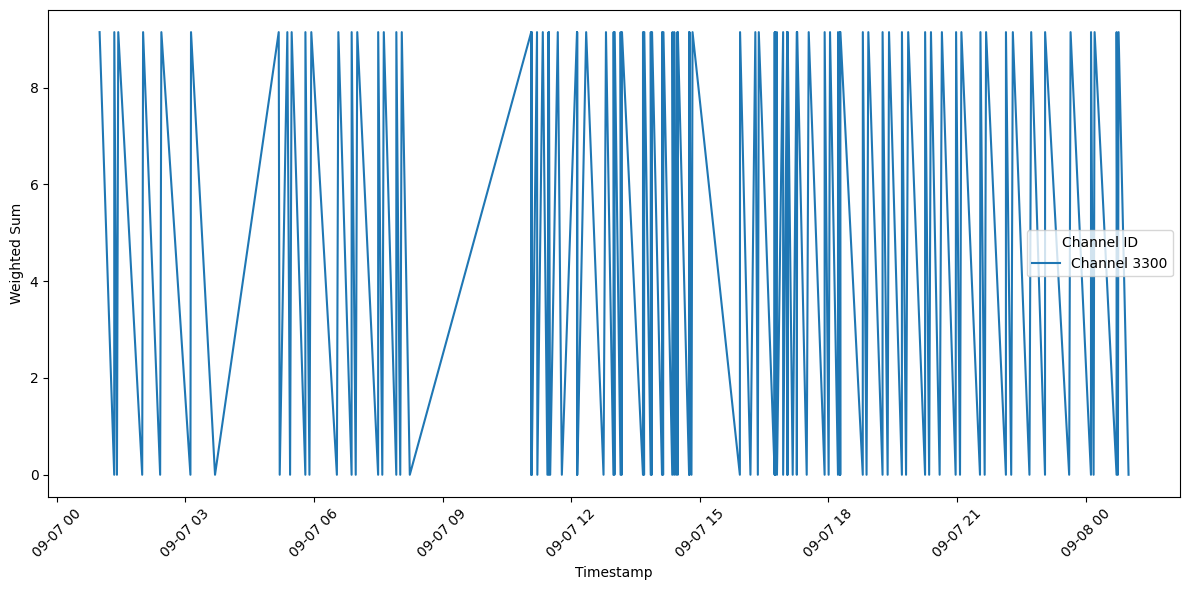

In [20]:
import matplotlib.pyplot as plt 

viewer_data = (
    digital_viewers_sum_df[
        digital_viewers_sum_df["viewer_id"] == "29245_21"
    ]
    .sort_values("ts")
)

fig, ax = plt.subplots(figsize=(12, 6))

channels = viewer_data["channel_id"].unique()
colors = plt.cm.tab20(range(len(channels)))

for channel_id, color in zip(channels, colors):
    channel_data = viewer_data[viewer_data["channel_id"] == channel_id]
    ax.plot(
        channel_data["ts"],
        channel_data["weighted_sum"],
        color=color,
        label=f"Channel {channel_id}",
    )

ax.set_xlabel("Timestamp")
ax.set_ylabel("Weighted Sum")
ax.legend(title="Channel ID")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# Big spike ts: 2025-09-07 12:42:40 - 12:44:43 ;  Weighted sum: 192089 ; Num viewers: 157 Fall-off baseline: 2869 -> 104
tg_df = active_sessions_df[(active_sessions_df["target_group"]=="m3049") & (active_sessions_df["channel_id"]==0)]
tg_df[(tg_df["session_finish"]==pd.to_datetime("2025-09-07 12:44:43"))].sort_values("session_duration")

,tv_date,channel_id,target_group,viewer_id,session_start,session_finish,session_duration,viewer_weight
578,2025-09-07,0,m3049,27827_30,2025-09-07 12:42:15,2025-09-07 12:44:43,148.0,17.280328
1693,2025-09-07,0,m3049,25215_30,2025-09-07 12:41:39,2025-09-07 12:44:43,184.0,17.275637
25423,2025-09-07,0,m3049,29680_21,2025-09-07 12:41:25,2025-09-07 12:44:43,198.0,17.188114
40399,2025-09-07,0,m3049,27401_30,2025-09-07 12:40:59,2025-09-07 12:44:43,224.0,17.114181
11260,2025-09-07,0,m3049,6315_5,2025-09-07 12:40:35,2025-09-07 12:44:43,248.0,17.111965
...,...,...,...,...,...,...,...,...
35279,2025-09-07,0,m3049,27171_28,2025-09-07 11:35:51,2025-09-07 12:44:43,4132.0,12.644450
38826,2025-09-07,0,m3049,29218_24,2025-09-07 11:35:51,2025-09-07 12:44:43,4132.0,12.322671
39402,2025-09-07,0,m3049,25339_28,2025-09-07 11:35:51,2025-09-07 12:44:43,4132.0,12.329350
38982,2025-09-07,0,m3049,29225_22,2025-09-07 11:35:51,2025-09-07 12:44:43,4132.0,8.826945


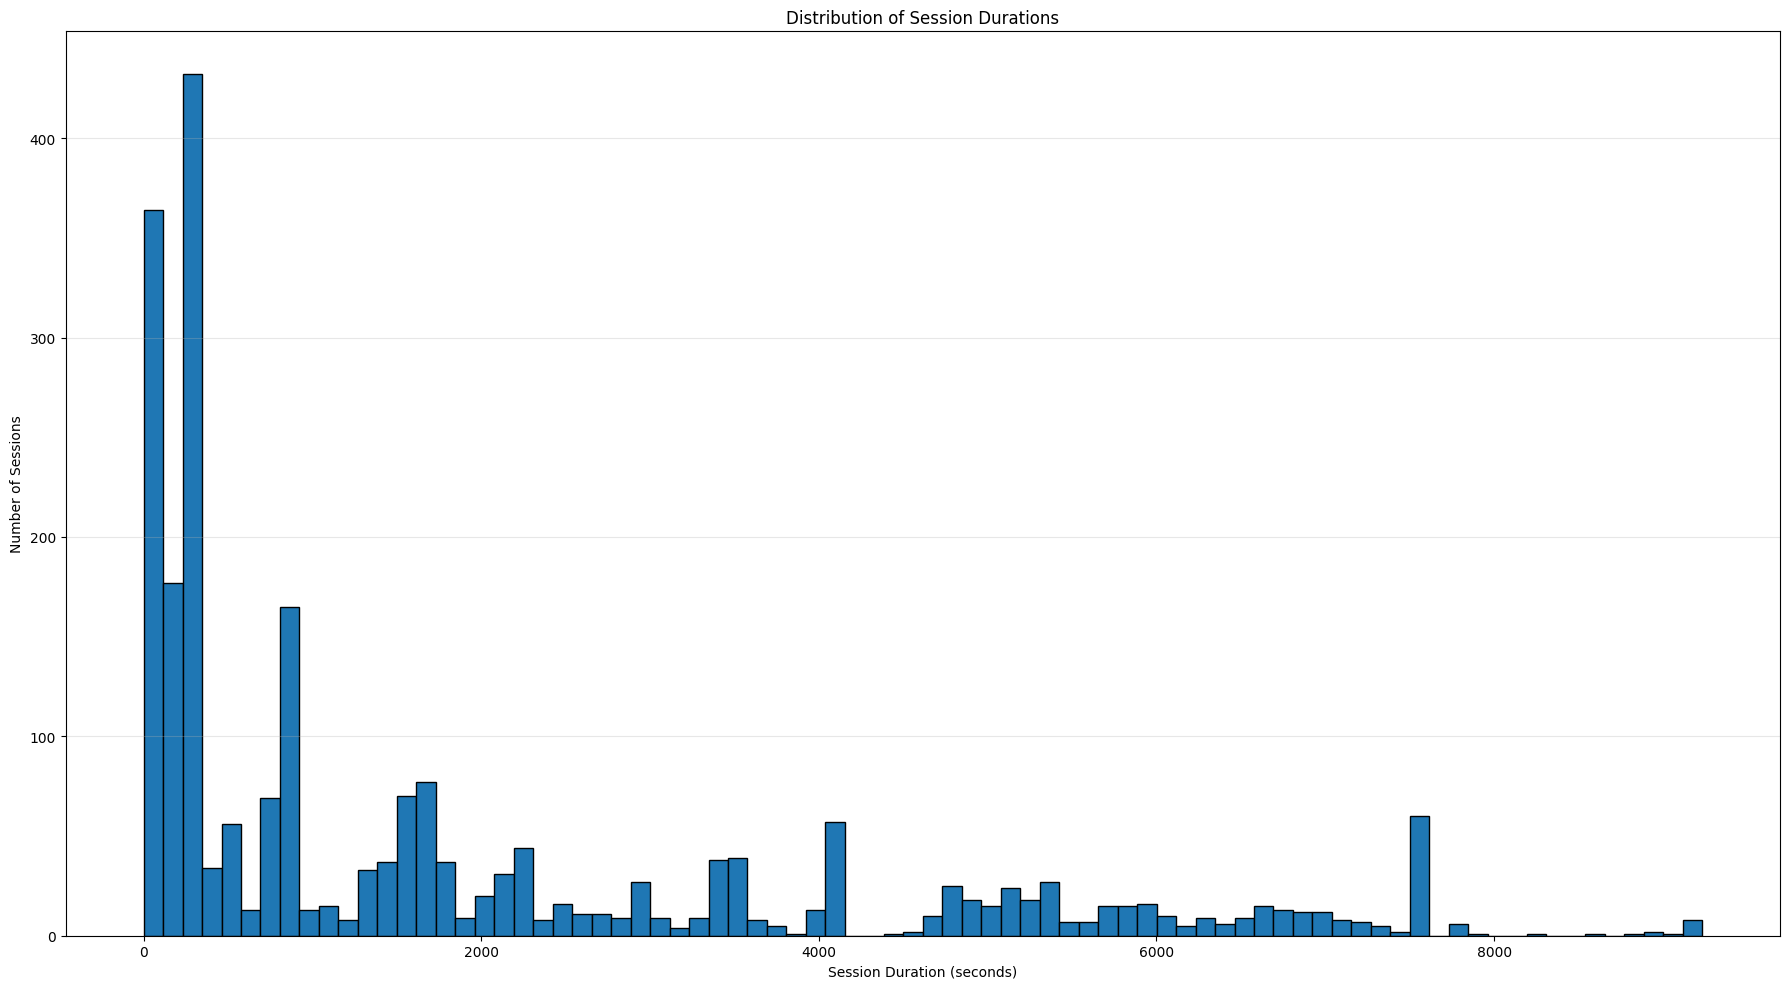

In [19]:
trunc_tg_df = tg_df[tg_df["session_duration"] < 10000]

plt.figure(figsize=(18, 10))
plt.hist(trunc_tg_df["session_duration"].dropna(), bins=80, edgecolor="black")

plt.xlabel("Session Duration (seconds)")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Session Durations")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()